# RNN vs LSTM vs GRU for Sequence Classification

**Assignment:** Implement and compare RNN, LSTM, and GRU models for sequence classification and analyze their performance using appropriate evaluation metrics.

**Dataset:** IMDB Movie Review Sentiment Dataset  
**Task:** Binary sentiment classification  
**Classes:** 0 = Negative, 1 = Positive

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Load the IMDB Dataset

The IMDB dataset contains movie reviews labeled as positive or negative.

We restrict the vocabulary to the **10,000 most frequent words** to keep training practical in Google Colab.

In [ ]:
VOCAB_SIZE = 10000
MAX_LEN = 200

(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Training samples:", len(X_train_raw))
print("Testing samples:", len(X_test_raw))
print("First review length:", len(X_train_raw[0]))
print("First label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
First review length: 218
First label: 1


## 2. Explore the Dataset

Minimum review length: 11
Maximum review length: 2494
Average review length: 238.71364

Class distribution:
0    12500
1    12500
Name: count, dtype: int64


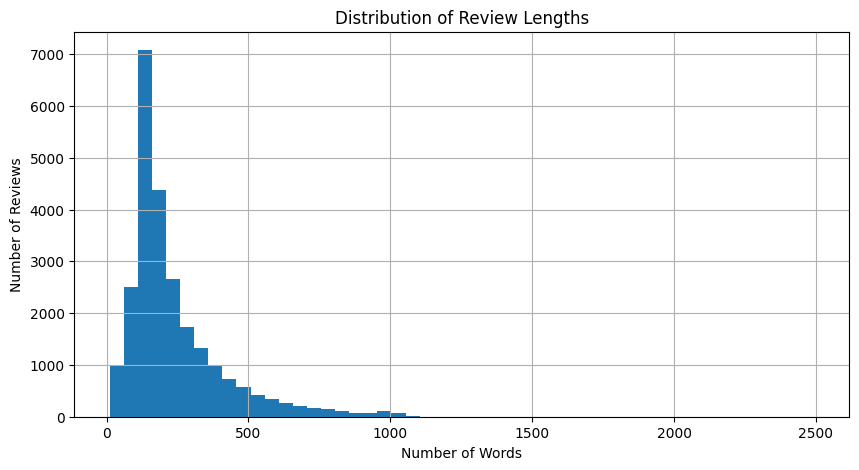

In [ ]:
train_lengths = [len(x) for x in X_train_raw]

print("Minimum review length:", min(train_lengths))
print("Maximum review length:", max(train_lengths))
print("Average review length:", np.mean(train_lengths))

print("\nClass distribution:")
print(pd.Series(y_train).value_counts().sort_index())

plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()

## 3. Pad the Sequences

RNN, LSTM, and GRU require inputs with a consistent sequence length. Therefore, reviews are padded/truncated to **200 tokens**.

In [ ]:
X_train = pad_sequences(
    X_train_raw,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test_raw,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (25000, 200)
X_test shape: (25000, 200)


## 4. Build the Simple RNN Model

In [ ]:
def build_rnn_model():
    model = Sequential([
        Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),
        SimpleRNN(64),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

rnn_model = build_rnn_model()
rnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Train the RNN Model

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.5045 - loss: 0.6980 - val_accuracy: 0.4938 - val_loss: 0.6941
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.5009 - loss: 0.6971 - val_accuracy: 0.4936 - val_loss: 0.7063
Epoch 3/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.5019 - loss: 0.6957 - val_accuracy: 0.4938 - val_loss: 0.6931
Epoch 4/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.5088 - loss: 0.6938 - val_accuracy: 0.4896 - val_loss: 0.6934
Epoch 5/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.5288 - loss: 0.6912 - val_accuracy: 0.5178 - val_loss: 0.6918
Epoch 6/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.5645 - loss: 0.6790 - val_accuracy: 0.5336 - val_loss: 0.6989
Epoch 7/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.6108 - loss: 0.6312 - val_accuracy: 0.5540 - val_loss: 0.6759
Epoch 8/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.6834 - loss: 0.5649 - 

## 6. Build the LSTM Model

In [ ]:
def build_lstm_model():
    model = Sequential([
        Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),
        LSTM(64),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

lstm_model = build_lstm_model()
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Train the LSTM Model

In [ ]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 57s 348ms/step - accuracy: 0.5239 - loss: 0.6901 - val_accuracy: 0.5864 - val_loss: 0.6631
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - accuracy: 0.6215 - loss: 0.6135 - val_accuracy: 0.6534 - val_loss: 0.5922
Epoch 3/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 374ms/step - accuracy: 0.7544 - loss: 0.5011 - val_accuracy: 0.7942 - val_loss: 0.5085
Epoch 4/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 54s 347ms/step - accuracy: 0.7814 - loss: 0.4964 - val_accuracy: 0.6730 - val_loss: 0.7540
Epoch 5/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 54s 345ms/step - accuracy: 0.7904 - loss: 0.5050 - val_accuracy: 0.8208 - val_loss: 0.4604
Epoch 6/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 54s 346ms/step - accuracy: 0.8550 - loss: 0.3988 - val_accuracy: 0.7912 - val_loss: 0.4865
Epoch 7/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 54s 346ms/step - accuracy: 0.6468 - loss: 0.6294 - val_accuracy: 0.5718 - val_loss: 0.6564


## 8. Build the GRU Model

In [ ]:
def build_gru_model():
    model = Sequential([
        Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),
        GRU(64),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

gru_model = build_gru_model()
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 9. Train the GRU Model

In [ ]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 66s 406ms/step - accuracy: 0.5056 - loss: 0.6927 - val_accuracy: 0.5402 - val_loss: 0.6882
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 393ms/step - accuracy: 0.5286 - loss: 0.6846 - val_accuracy: 0.5438 - val_loss: 0.6836


## 10. Plot Training and Validation Accuracy

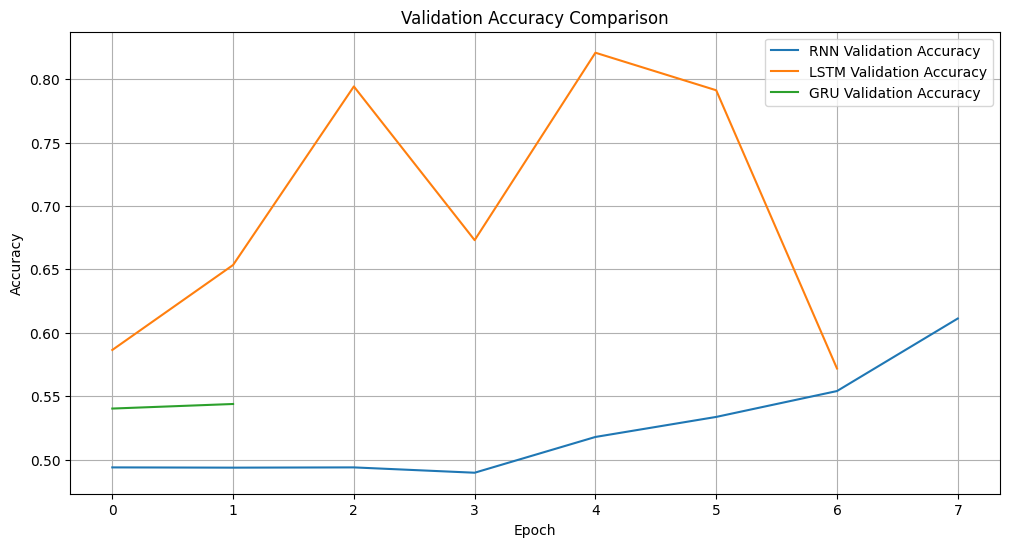

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(rnn_history.history["val_accuracy"], label="RNN Validation Accuracy")
plt.plot(lstm_history.history["val_accuracy"], label="LSTM Validation Accuracy")
plt.plot(gru_history.history["val_accuracy"], label="GRU Validation Accuracy")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 11. Plot Training and Validation Loss

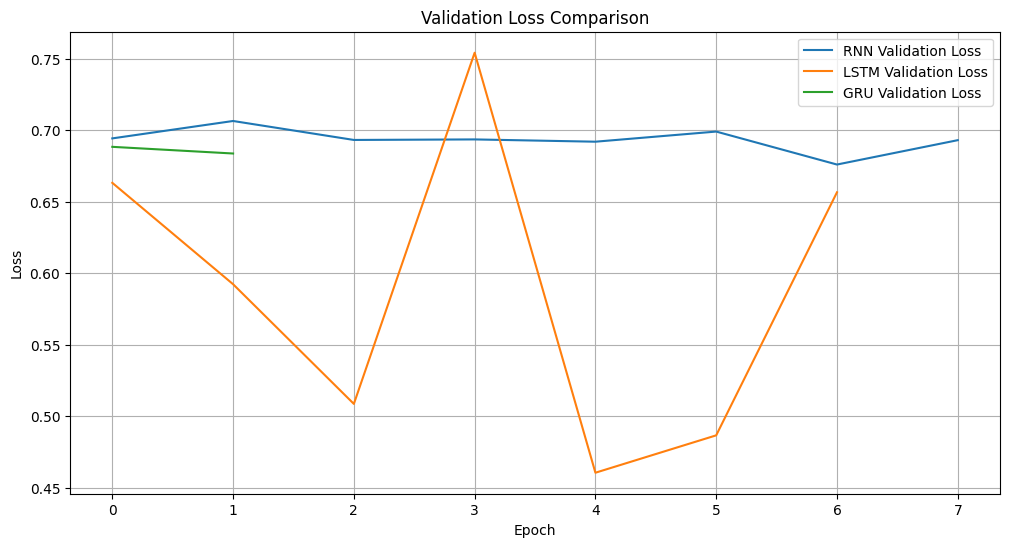

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(rnn_history.history["val_loss"], label="RNN Validation Loss")
plt.plot(lstm_history.history["val_loss"], label="LSTM Validation Loss")
plt.plot(gru_history.history["val_loss"], label="GRU Validation Loss")

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 12. Evaluate All Three Models

We calculate:

- Accuracy
- Precision
- Recall
- F1 Score

In [ ]:
models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

results = []

predictions_dict = {}

for name, model in models.items():
    probabilities = model.predict(X_test, batch_size=128, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)

    predictions_dict[name] = predictions

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")

display(results_df.round(4))

,Accuracy,Precision,Recall,F1 Score
Model,,,,
RNN,0.5479,0.5381,0.6769,0.5995
LSTM,0.8024,0.7925,0.8194,0.8057
GRU,0.5269,0.5495,0.2989,0.3872


## 13. Visualize Evaluation Metrics

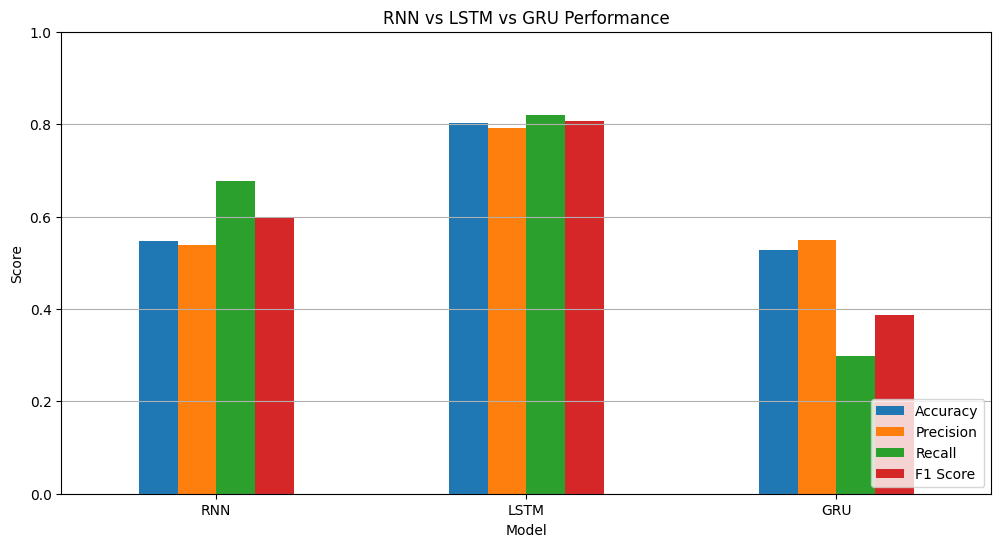

In [14]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

ax = results_df[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("RNN vs LSTM vs GRU Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(loc="lower right")

plt.show()

## 14. Confusion Matrices

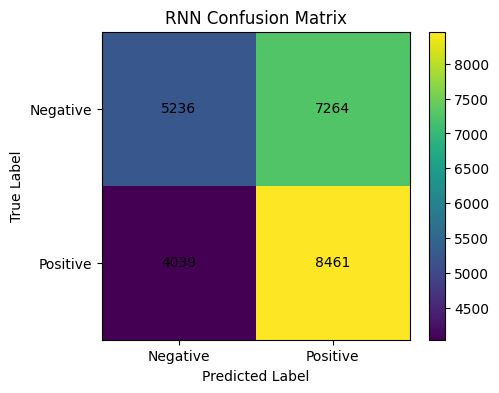

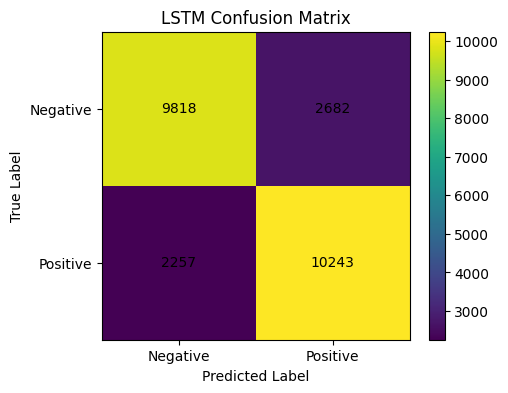

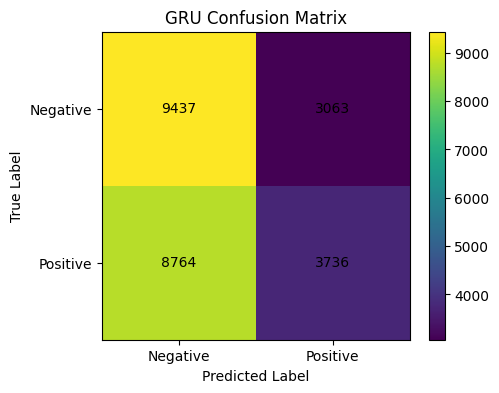

In [15]:
for name, predictions in predictions_dict.items():
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0, 1], ["Negative", "Positive"])
    plt.yticks([0, 1], ["Negative", "Positive"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.show()

## 15. Classification Reports

In [16]:
for name, predictions in predictions_dict.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(
        classification_report(
            y_test,
            predictions,
            target_names=["Negative", "Positive"]
        )
    )

RNN
              precision    recall  f1-score   support

    Negative       0.56      0.42      0.48     12500
    Positive       0.54      0.68      0.60     12500

    accuracy                           0.55     25000
   macro avg       0.55      0.55      0.54     25000
weighted avg       0.55      0.55      0.54     25000

LSTM
              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80     12500
    Positive       0.79      0.82      0.81     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000

GRU
              precision    recall  f1-score   support

    Negative       0.52      0.75      0.61     12500
    Positive       0.55      0.30      0.39     12500

    accuracy                           0.53     25000
   macro avg       0.53      0.53      0.50     25000
weighted avg       0.53      0.53      0.50     25000



## 16. Compare Number of Trainable Parameters

,Model,Trainable Parameters
0,RNN,650369
1,LSTM,675137
2,GRU,667073


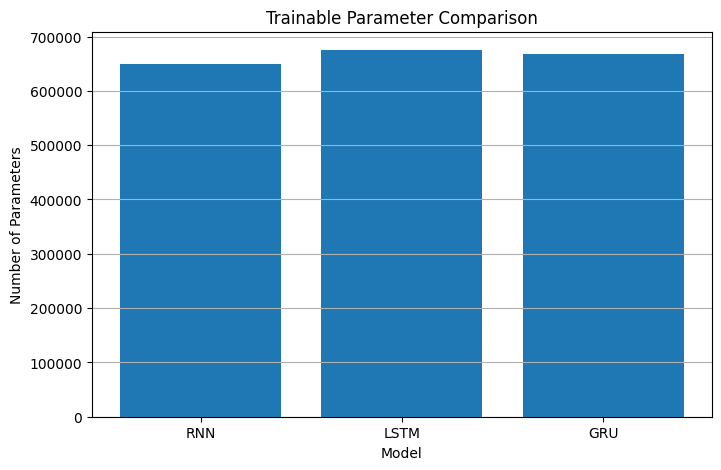

In [17]:
parameter_results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Trainable Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ]
})

display(parameter_results)

plt.figure(figsize=(8, 5))
plt.bar(
    parameter_results["Model"],
    parameter_results["Trainable Parameters"]
)
plt.title("Trainable Parameter Comparison")
plt.xlabel("Model")
plt.ylabel("Number of Parameters")
plt.grid(axis="y")
plt.show()

## 17. Training Time Comparison

In [18]:
# Training durations are not measured retrospectively by Keras.
# This cell gives the number of epochs actually completed.

training_summary = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Epochs Completed": [
        len(rnn_history.history["loss"]),
        len(lstm_history.history["loss"]),
        len(gru_history.history["loss"])
    ],
    "Final Validation Accuracy": [
        rnn_history.history["val_accuracy"][-1],
        lstm_history.history["val_accuracy"][-1],
        gru_history.history["val_accuracy"][-1]
    ],
    "Final Validation Loss": [
        rnn_history.history["val_loss"][-1],
        lstm_history.history["val_loss"][-1],
        gru_history.history["val_loss"][-1]
    ]
})

display(training_summary.round(4))

,Model,Epochs Completed,Final Validation Accuracy,Final Validation Loss
0,RNN,8,0.6112,0.6929
1,LSTM,7,0.5718,0.6564
2,GRU,2,0.5438,0.6836


## 18. Final Comparison

The following table summarizes the test-set performance of the three sequence models.

In [19]:
display(results_df.round(4))

print("\nInterpretation:")
print("- RNN uses the simplest recurrent architecture.")
print("- LSTM uses memory cells and gates to handle longer dependencies.")
print("- GRU uses a simpler gated architecture and often provides a useful balance between speed and performance.")
print("- Accuracy, precision, recall, and F1 score should be considered together rather than relying on a single metric.")

,Accuracy,Precision,Recall,F1 Score
Model,,,,
RNN,0.5479,0.5381,0.6769,0.5995
LSTM,0.8024,0.7925,0.8194,0.8057
GRU,0.5269,0.5495,0.2989,0.3872



Interpretation:
- RNN uses the simplest recurrent architecture.
- LSTM uses memory cells and gates to handle longer dependencies.
- GRU uses a simpler gated architecture and often provides a useful balance between speed and performance.
- Accuracy, precision, recall, and F1 score should be considered together rather than relying on a single metric.
